# Seizure prediction pipeline

This pipeline performs patient-specific seizure prediction on the CHB-MIT Scalp EEG Database, learning to separate preictal EEG (the 30 minutes before a seizure, excluding a 5-minute pre-onset gap) from interictal EEG (seizure-free periods). Recordings are bandpass-filtered (0.5–50 Hz) with a 60 Hz notch, then split into 10-second windows. Each window is reduced to a feature vector across 17 channels: relative band power (δ θ α β γ), spectral edge frequency, line length, Hjorth parameters, and statistical moments. An XGBoost classifier (RandomForest fallback) is trained with leave-one-seizure-out cross-validation, splitting by recording so no file appears in both training and test, this prevents the leakage that inflates most reported results.
Alarms use a firing-power scheme: per-window probabilities are smoothed over 10 minutes, with a threshold and refractory period, so isolated false positives are suppressed and a seizure counts as predicted if any alarm fires within its preictal window.
Results (chb01): in the end 6 of 7 seizures predicted (sensitivity 0.86) at 0.12 false alarms/hour, with a supporting window-level AUC of 0.96. The one miss had its onset too early in the file to leave usable preictal signal. Ofc, this is a single-patient proof of concept and it require cohort-wide validation.


In [10]:
!pip -q install mne xgboost

In [11]:
import os, re, warnings, urllib.request
import numpy as np
warnings.filterwarnings("ignore")
import mne
mne.set_log_level("ERROR")
from scipy.signal import welch
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

PATIENT          = "chb01"
BASE_URL         = f"https://physionet.org/files/chbmit/1.0.0/{PATIENT}"
DATA_DIR         = PATIENT
FS               = 256
WINDOW_SEC       = 10
STEP_SEC         = 10
PREICTAL_MIN     = 30
SPH_MIN          = 5
INTERICTAL_FILES = 8
NOTCH_HZ         = 60
BANDPASS         = (0.5, 50.0)
INTERICTAL_CAP   = 250
RANDOM_STATE     = 42
np.random.seed(RANDOM_STATE)

In [12]:
os.makedirs(DATA_DIR, exist_ok=True)

def download(fname):
    url = f"{BASE_URL}/{fname}"
    dst = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dst):
        print("downloading", fname)
        urllib.request.urlretrieve(url, dst)
    return dst

summary_path = download(f"{PATIENT}-summary.txt")
print(open(summary_path).read()[:1500])

Data Sampling Rate: 256 Hz
*************************

Channels in EDF Files:
**********************
Channel 1: FP1-F7
Channel 2: F7-T7
Channel 3: T7-P7
Channel 4: P7-O1
Channel 5: FP1-F3
Channel 6: F3-C3
Channel 7: C3-P3
Channel 8: P3-O1
Channel 9: FP2-F4
Channel 10: F4-C4
Channel 11: C4-P4
Channel 12: P4-O2
Channel 13: FP2-F8
Channel 14: F8-T8
Channel 15: T8-P8
Channel 16: P8-O2
Channel 17: FZ-CZ
Channel 18: CZ-PZ
Channel 19: P7-T7
Channel 20: T7-FT9
Channel 21: FT9-FT10
Channel 22: FT10-T8
Channel 23: T8-P8

File Name: chb01_01.edf
File Start Time: 11:42:54
File End Time: 12:42:54
Number of Seizures in File: 0

File Name: chb01_02.edf
File Start Time: 12:42:57
File End Time: 13:42:57
Number of Seizures in File: 0

File Name: chb01_03.edf
File Start Time: 13:43:04
File End Time: 14:43:04
Number of Seizures in File: 1
Seizure Start Time: 2996 seconds
Seizure End Time: 3036 seconds

File Name: chb01_04.edf
File Start Time: 14:43:12
File End Time: 15:43:12
Number of Seizures in File: 1
S

In [13]:
def parse_summary(path):
    seizures, order, cur, start = {}, [], None, None
    for line in open(path):
        line = line.strip()
        if line.startswith("File Name:"):
            cur = line.split(":", 1)[1].strip()
            seizures.setdefault(cur, [])
            order.append(cur)
        elif line.startswith("Seizure") and "Start Time" in line:
            start = int(re.search(r"(\d+)\s*sec", line).group(1))
        elif line.startswith("Seizure") and "End Time" in line:
            end = int(re.search(r"(\d+)\s*sec", line).group(1))
            seizures[cur].append((start, end))
    return seizures, order

seizures, file_order = parse_summary(summary_path)
seizure_files    = [f for f in file_order if seizures[f]]
nonseizure_files = [f for f in file_order if not seizures[f]]
interictal_files = nonseizure_files[:INTERICTAL_FILES]

print("Seizure files   :", seizure_files)
print("Interictal files:", interictal_files)
for f in seizure_files + interictal_files:
    download(f)

Seizure files   : ['chb01_03.edf', 'chb01_04.edf', 'chb01_15.edf', 'chb01_16.edf', 'chb01_18.edf', 'chb01_21.edf', 'chb01_26.edf']
Interictal files: ['chb01_01.edf', 'chb01_02.edf', 'chb01_05.edf', 'chb01_06.edf', 'chb01_07.edf', 'chb01_08.edf', 'chb01_09.edf', 'chb01_10.edf']


In [14]:
CANONICAL_CH = ['FP1-F7','F7-T7','T7-P7','P7-O1','FP1-F3','F3-C3','C3-P3','P3-O1',
                'FP2-F4','F4-C4','C4-P4','P4-O2','FP2-F8','F8-T8','T8-P8','P8-O2',
                'FZ-CZ','CZ-PZ']
BANDS = {'delta':(0.5,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,50)}

def common_channels(files):
    sets = []
    for f in files:
        raw = mne.io.read_raw_edf(os.path.join(DATA_DIR, f), preload=False, verbose="ERROR")
        sets.append(set(raw.ch_names))
    common = set.intersection(*sets) if sets else set()
    return [c for c in CANONICAL_CH if c in common]

CHANNELS = common_channels(seizure_files + interictal_files)
print(f"Using {len(CHANNELS)} channels:", CHANNELS)

Using 17 channels: ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']


In [15]:
def features_window(data, fs):
    feats = []
    for ch in data:
        f, pxx = welch(ch, fs=fs, nperseg=min(len(ch), fs*2))
        total = np.trapz(pxx, f) + 1e-12
        for lo, hi in BANDS.values():
            idx = (f >= lo) & (f < hi)
            feats.append(np.trapz(pxx[idx], f[idx]) / total)
        cum = np.cumsum(pxx) / (np.sum(pxx) + 1e-12)
        feats.append(f[min(np.searchsorted(cum, 0.95), len(f)-1)])
        feats.append(np.sum(np.abs(np.diff(ch))))
        d1, d2 = np.diff(ch), np.diff(np.diff(ch))
        v0, v1, v2 = np.var(ch)+1e-12, np.var(d1)+1e-12, np.var(d2)+1e-12
        mob = np.sqrt(v1/v0)
        feats += [v0, mob, np.sqrt(v2/v1)/mob]
        feats += [np.std(ch), skew(ch), kurtosis(ch), np.sqrt(np.mean(ch**2))]
    return np.nan_to_num(np.array(feats, dtype=float))

def extract_file(fname, mode):
    raw = mne.io.read_raw_edf(os.path.join(DATA_DIR, fname), preload=True, verbose="ERROR")
    raw.pick([c for c in CHANNELS if c in raw.ch_names])
    raw.filter(*BANDPASS, verbose="ERROR")
    raw.notch_filter(NOTCH_HZ, verbose="ERROR")
    fs = int(raw.info['sfreq'])
    data = raw.get_data()
    win, step = WINDOW_SEC*fs, STEP_SEC*fs
    keep = None
    if mode == "preictal":
        onset = seizures[fname][0][0]
        lo = max(0, int((onset - (SPH_MIN+PREICTAL_MIN)*60) * fs))
        hi = max(0, int((onset -  SPH_MIN*60)            * fs))
        keep = (lo, hi)
    X = []
    for s in range(0, data.shape[1]-win+1, step):
        if keep and not (keep[0] <= s and s+win <= keep[1]):
            continue
        X.append(features_window(data[:, s:s+win], fs))
    X = np.array(X)
        X = X[np.random.choice(len(X), INTERICTAL_CAP, replace=False)]
    return X

In [17]:
X_list, y_list, groups = [], [], []
for f in seizure_files:
    Xf = extract_file(f, "preictal")
    if len(Xf):
        X_list.append(Xf); y_list.append(np.ones(len(Xf))); groups += [f]*len(Xf)
for f in interictal_files:
    Xf = extract_file(f, "interictal")
    if len(Xf):
        X_list.append(Xf); y_list.append(np.zeros(len(Xf))); groups += [f]*len(Xf)

X = np.vstack(X_list)
y = np.concatenate(y_list)
groups = np.array(groups)
print(f"X shape {X.shape}  |  preictal {int(y.sum())}  interictal {int((y==0).sum())}")

X shape (2809, 238)  |  preictal 809  interictal 2000


In [18]:
try:
    from xgboost import XGBClassifier
    def make_clf(spw):
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                             eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
    print("classifier: XGBoost")
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    def make_clf(spw):
        return RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE)
    print("classifier: RandomForest (xgboost unavailable)")


folds = []
for i, sf in enumerate(seizure_files):
    test_files = {sf} | set(interictal_files[i::len(seizure_files)])
    folds.append(test_files)

oof_true, oof_score = [], []
sens_list, spec_list, fprh_list = [], [], []
for k, test_files in enumerate(folds):
    te = np.isin(groups, list(test_files))
    tr = ~te
    if y[te].sum() == 0 or (y[te] == 0).sum() == 0:
        continue
    sc = StandardScaler().fit(X[tr])
    spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
    clf = make_clf(spw).fit(sc.transform(X[tr]), y[tr])
    p = clf.predict_proba(sc.transform(X[te]))[:, 1]
    oof_true += list(y[te]); oof_score += list(p)
    pred = (p >= 0.5).astype(int)
    tp = int(((pred==1)&(y[te]==1)).sum()); fn = int(((pred==0)&(y[te]==1)).sum())
    tn = int(((pred==0)&(y[te]==0)).sum()); fp = int(((pred==1)&(y[te]==0)).sum())
    sens = tp/max(tp+fn,1); spec = tn/max(tn+fp,1)
    fprh = fp / max((y[te]==0).sum()*WINDOW_SEC/3600, 1e-9)
    sens_list.append(sens); spec_list.append(spec); fprh_list.append(fprh)
    print(f"Fold {k+1} {sorted(test_files)}: sens={sens:.2f} spec={spec:.2f} FPR/h={fprh:.2f}")

classifier: XGBoost
Fold 1 ['chb01_01.edf', 'chb01_03.edf', 'chb01_10.edf']: sens=0.75 spec=1.00 FPR/h=0.00
Fold 2 ['chb01_02.edf', 'chb01_04.edf']: sens=0.58 spec=0.64 FPR/h=128.16
Fold 3 ['chb01_05.edf', 'chb01_15.edf']: sens=1.00 spec=0.99 FPR/h=4.32
Fold 4 ['chb01_06.edf', 'chb01_16.edf']: sens=1.00 spec=1.00 FPR/h=1.44
Fold 5 ['chb01_07.edf', 'chb01_18.edf']: sens=0.96 spec=1.00 FPR/h=0.00
Fold 6 ['chb01_08.edf', 'chb01_21.edf']: sens=1.00 spec=1.00 FPR/h=0.00
Fold 7 ['chb01_09.edf', 'chb01_26.edf']: sens=0.49 spec=1.00 FPR/h=0.00



Pooled AUC        : 0.960
Mean sensitivity  : 0.83
Mean specificity  : 0.95
Mean FPR/hour     : 19.13


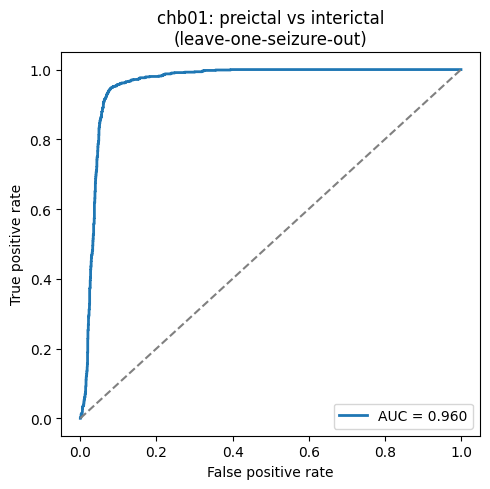

In [19]:
auc = roc_auc_score(oof_true, oof_score)
print(f"\nPooled AUC        : {auc:.3f}")
print(f"Mean sensitivity  : {np.mean(sens_list):.2f}")
print(f"Mean specificity  : {np.mean(spec_list):.2f}")
print(f"Mean FPR/hour     : {np.mean(fprh_list):.2f}")

fpr, tpr, _ = roc_curve(oof_true, oof_score)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "--", c="gray")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title(f"{PATIENT}: preictal vs interictal\n(leave-one-seizure-out)")
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
def features_window(data, fs):
    f, pxx = welch(data, fs=fs, nperseg=min(data.shape[1], fs*2), axis=-1)
    total = np.trapz(pxx, f, axis=-1) + 1e-12
    bp = np.stack([np.trapz(pxx[:, (f>=lo)&(f<hi)], f[(f>=lo)&(f<hi)], axis=-1)/total
                   for lo, hi in BANDS.values()], axis=1)
    cum = np.cumsum(pxx, axis=-1) / (pxx.sum(axis=-1, keepdims=True) + 1e-12)
    sef = f[np.argmax(cum >= 0.95, axis=-1)]
    ll  = np.abs(np.diff(data, axis=-1)).sum(axis=-1)
    d1, d2 = np.diff(data, axis=-1), np.diff(np.diff(data, axis=-1), axis=-1)
    v0 = data.var(axis=-1)+1e-12; v1 = d1.var(axis=-1)+1e-12; v2 = d2.var(axis=-1)+1e-12
    mob = np.sqrt(v1/v0); comp = np.sqrt(v2/v1)/mob
    feat = np.concatenate([bp.ravel(), sef, ll, v0, mob, comp,
                           data.std(axis=-1), skew(data, axis=-1),
                           kurtosis(data, axis=-1), np.sqrt((data**2).mean(axis=-1))])
    return np.nan_to_num(feat)

def extract_file(fname, mode):
    raw = mne.io.read_raw_edf(os.path.join(DATA_DIR, fname), preload=True, verbose="ERROR")
    raw.pick([c for c in CHANNELS if c in raw.ch_names])
    raw.filter(*BANDPASS, verbose="ERROR"); raw.notch_filter(NOTCH_HZ, verbose="ERROR")
    fs = int(raw.info['sfreq']); data = raw.get_data()
    win, step = WINDOW_SEC*fs, STEP_SEC*fs
    starts = list(range(0, data.shape[1]-win+1, step))
    if mode == "preictal":
        onset = seizures[fname][0][0]
        lo = max(0, int((onset-(SPH_MIN+PREICTAL_MIN)*60)*fs))
        hi = max(0, int((onset- SPH_MIN*60)*fs))
        starts = [s for s in starts if lo <= s and s+win <= hi]
    print(f"  {fname}: {len(starts)} windows ({mode})")
    X = np.array([features_window(data[:, s:s+win], fs) for s in starts])
    return X

In [21]:
WIN_PER_HOUR = 3600 // STEP_SEC

files = {}
for f in seizure_files:
    Xf = extract_file(f, "preictal")
    if len(Xf): files[f] = dict(X=Xf, y=np.ones(len(Xf)), mode="seizure")
for f in interictal_files:
    Xf = extract_file(f, "interictal")
    if len(Xf): files[f] = dict(X=Xf, y=np.zeros(len(Xf)), mode="interictal")

X_all = np.vstack([d["X"] for d in files.values()])
print("total windows:", len(X_all))

  chb01_03.edf: 179 windows (preictal)
  chb01_04.edf: 116 windows (preictal)
  chb01_15.edf: 143 windows (preictal)
  chb01_16.edf: 71 windows (preictal)
  chb01_18.edf: 142 windows (preictal)
  chb01_21.edf: 2 windows (preictal)
  chb01_26.edf: 156 windows (preictal)
  chb01_01.edf: 360 windows (interictal)
  chb01_02.edf: 360 windows (interictal)
  chb01_05.edf: 360 windows (interictal)
  chb01_06.edf: 360 windows (interictal)
  chb01_07.edf: 360 windows (interictal)
  chb01_08.edf: 360 windows (interictal)
  chb01_09.edf: 360 windows (interictal)
  chb01_10.edf: 360 windows (interictal)
total windows: 3689


In [22]:
PREICTAL_WIN = (PREICTAL_MIN*60)//STEP_SEC
FP_K   = max(3, PREICTAL_WIN//3)
THR    = 0.6
REFRACT = PREICTAL_WIN
def firing_power(probs, k):
    return np.convolve(probs, np.ones(k)/k, mode="same")

def count_alarms(fp, thr, refract):
    alarms, last = [], -10**9
    for i, v in enumerate(fp):
        if v >= thr and i - last > refract:
            alarms.append(i); last = i
    return alarms

try:
    from xgboost import XGBClassifier
    def make_clf(spw): return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
        eval_metric="logloss", n_jobs=-1, random_state=RANDOM_STATE)
except Exception:
    from sklearn.ensemble import RandomForestClassifier
    def make_clf(spw): return RandomForestClassifier(n_estimators=400,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)

folds = []
for i, sf in enumerate(seizure_files):
    test = {sf} | set(interictal_files[i::len(seizure_files)])
    folds.append(test)

n_predicted, total_alarms, inter_hours = 0, 0, 0.0
for k, test_files in enumerate(folds):
    test_files = [f for f in test_files if f in files]
    train_files = [f for f in files if f not in test_files]
    Xtr = np.vstack([files[f]["X"] for f in train_files])
    ytr = np.concatenate([files[f]["y"] for f in train_files])
    sc = StandardScaler().fit(Xtr)
    spw = (ytr==0).sum()/max((ytr==1).sum(),1)
    clf = make_clf(spw).fit(sc.transform(Xtr), ytr)

    for f in test_files:
        probs = clf.predict_proba(sc.transform(files[f]["X"]))[:,1]
        fp = firing_power(probs, FP_K)
        alarms = count_alarms(fp, THR, REFRACT)
        if files[f]["mode"] == "seizure":
            n_predicted += int(len(alarms) > 0)
        else:
            total_alarms += len(alarms)
            inter_hours  += len(probs)/WIN_PER_HOUR
    print(f"fold {k+1}: {sorted(test_files)} done")

sensitivity = n_predicted/len(seizure_files)
fpr_h = total_alarms/max(inter_hours,1e-9)
print(f"\nSeizure sensitivity (per-crisi): {sensitivity:.2f}  ({n_predicted}/{len(seizure_files)})")
print(f"FPR/hour (post firing-power)   : {fpr_h:.2f}")
print(f"interictal hours valutate      : {inter_hours:.1f}")

fold 1: ['chb01_01.edf', 'chb01_03.edf', 'chb01_10.edf'] done
fold 2: ['chb01_02.edf', 'chb01_04.edf'] done
fold 3: ['chb01_05.edf', 'chb01_15.edf'] done
fold 4: ['chb01_06.edf', 'chb01_16.edf'] done
fold 5: ['chb01_07.edf', 'chb01_18.edf'] done
fold 6: ['chb01_08.edf', 'chb01_21.edf'] done
fold 7: ['chb01_09.edf', 'chb01_26.edf'] done

Seizure sensitivity (per-crisi): 0.86  (6/7)
FPR/hour (post firing-power)   : 0.12
interictal hours valutate      : 8.0


In [23]:
import json, pandas as pd
from google.colab import files

summary = {
    "patient": PATIENT,
    "window_sec": WINDOW_SEC,
    "preictal_min": PREICTAL_MIN,
    "sph_min": SPH_MIN,
    "notch_hz": NOTCH_HZ,
    "n_channels": len(CHANNELS),
    "n_seizures": len(seizure_files),
    "seizures_predicted": int(n_predicted),
    "sensitivity_per_seizure": round(float(sensitivity), 3),
    "false_alarms": int(total_alarms),
    "interictal_hours": round(float(inter_hours), 2),
    "fpr_per_hour": round(float(fpr_h), 3),
    "fp_threshold": THR,
    "fp_window": FP_K,
}

pd.DataFrame([summary]).to_csv(f"{PATIENT}_results.csv", index=False)
with open(f"{PATIENT}_results.json", "w") as fh:
    json.dump(summary, fh, indent=2)

files.download(f"{PATIENT}_results.csv")
files.download(f"{PATIENT}_results.json")
print(summary)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

{'patient': 'chb01', 'window_sec': 10, 'preictal_min': 30, 'sph_min': 5, 'notch_hz': 60, 'n_channels': 17, 'n_seizures': 7, 'seizures_predicted': 6, 'sensitivity_per_seizure': 0.857, 'false_alarms': 1, 'interictal_hours': 8.0, 'fpr_per_hour': 0.125, 'fp_threshold': 0.6, 'fp_window': 60}
